---
title: Number of Latent States
subtitle: GLM integration
description: Looking the best number of latent states for Hidden Markov Models with GLM emissions.
format: html
jupyter: python3
editor_options:
       chunk_output_type: inline
author: ["Tommaso Piscitelli"]
categories: ["Pyro", "Python", "Bayesian Models", "GLM", "HMM"]
date: 2025-08-10
---


In [3]:
import pandas as pd
import numpy as np
from hmmlearn import hmm
import matplotlib.pyplot as plt
from pyprojroot import here
import pyro
import pyro.distributions as dist
import pyro.distributions.constraints as constraints
from pyro.infer import SVI, TraceEnum_ELBO
from pyro.optim import Adam
from scipy.stats import poisson
import torch
import seaborn as sns

data = pd.read_csv(here("data/recent_donations.csv"))
data

# remove columns y_2020 to y_2023
# data = data.drop(columns=["y_2020", "y_2021", "y_2022", "y_2023"])

,unique_number,class_year,birth_year,first_donation_year,gender,y_2009,y_2010,y_2011,y_2012,y_2013,y_2014,y_2015,y_2016,y_2018,y_2019,y_2017,y_2020,y_2021,y_2022,y_2023
0,26308560,"(1960,1970]",1965,1985,M,0,0,0,0,0,0,0,0,0,0,0,1,1,3,1
1,26309283,"(1960,1970]",1966,2002,M,2,1,2,2,1,1,3,3,4,1,3,3,3,3,4
2,26317365,"(1960,1970]",1961,1984,M,4,2,3,3,3,4,3,3,2,3,3,2,0,1,0
3,26318451,"(1960,1970]",1967,1989,M,0,3,3,4,4,4,2,3,3,1,2,3,1,0,0
4,26319465,"(1960,1970]",1964,1994,F,1,2,2,1,2,1,1,0,0,2,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9231,27220599,"(1970,1980]",1980,2022,M,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
9232,27220806,"(2000,2010]",2002,2022,M,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3
9233,27221247,"(1990,2000]",2000,2022,F,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
9234,27221274,"(1960,1970]",1966,2022,F,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3


In [4]:
# ───────────────────────────────────────────────────────────────
#  Required libraries
# ───────────────────────────────────────────────────────────────
import polars as pl
import numpy as np
import torch

# ───────────────────────────────────────────────────────────────
# 1. Load data
# ───────────────────────────────────────────────────────────────
df = pl.from_pandas(data)                # or pl.read_csv("file.csv")

# ───────────────────────────────────────────────────────────────
# 2. Observed counts   obs  ∈  ℕ^{N×T}
# ───────────────────────────────────────────────────────────────
year_cols = sorted([c for c in df.columns if c.startswith("y_")])
T = len(year_cols)
obs = (df.select(year_cols)
         .fill_null(0)
         .to_numpy()
         .astype(int))                   # (N,T)

# ───────────────────────────────────────────────────────────────
# 3. Fixed covariates (for π)
# ───────────────────────────────────────────────────────────────
df = df.with_columns([
    (pl.col("gender") == "F").cast(pl.Int8).alias("gender_code"),
    ((pl.col("birth_year") - pl.col("birth_year").mean()) /
     pl.col("birth_year").std()).alias("birth_year_norm")
])

birth_year_norm = df["birth_year_norm"].to_numpy()        # (N,)
gender_code     = df["gender_code"].to_numpy()            # (N,)

# π-covariate matrix  (N,2)
cov_init = np.stack([birth_year_norm, gender_code], axis=1)

# ───────────────────────────────────────────────────────────────
# 4. Dynamic covariates (for A)
# ───────────────────────────────────────────────────────────────
years_num  = np.array([int(c[2:]) for c in year_cols])    # [2009, …, 2023]
ages       = years_num[None, :] - df["birth_year"].to_numpy()[:, None]
ages_norm  = (ages - ages.mean()) / ages.std()            # (N,T)

covid_mask = np.isin(years_num, [2020, 2021, 2022]).astype(float)  # (T,)
covid_years = np.tile(covid_mask, (df.height, 1))          # (N,T)

# A-covariate tensor (N,T,2)
cov_tran = np.stack([ages_norm, covid_years], axis=2)

# ───────────────────────────────────────────────────────────────
# 5. Torch tensors
# ───────────────────────────────────────────────────────────────
obs_torch      = torch.tensor(obs,      dtype=torch.long)
cov_init_torch = torch.tensor(cov_init, dtype=torch.float)   # (N,2)
cov_tran_torch = torch.tensor(cov_tran, dtype=torch.float)   # (N,T,2)

# ───────────────────────────────────────────────────────────────
# 6. Emission covariates (for emission GLMs in HMM)
#    (N, T, 4): [birth_year_norm, gender_code, ages_norm, covid_years]
# ───────────────────────────────────────────────────────────────

# Fixed part, repeated along time
# birth_year_norm_tile = np.repeat(birth_year_norm[:, None], T, axis=1)  # (N,T)
gender_code_tile     = np.repeat(gender_code[:, None],     T, axis=1)  # (N,T)

# Assemble emission covariate tensor (N,T,4)
cov_emission = np.stack(
    [gender_code_tile, ages_norm, covid_years],
    axis=2
)  # (N,T,4)

cov_emiss_torch = torch.tensor(cov_emission, dtype=torch.float)

print("Emission covariates:", cov_emiss_torch.shape)   # should be (N,T,4)

print("obs        :", obs_torch.shape)      # (N,T)
print("π covs     :", cov_init_torch.shape) # (N,2)
print("A covs     :", cov_tran_torch.shape) # (N,T,2)

Emission covariates: torch.Size([9236, 15, 3])
obs        : torch.Size([9236, 15])
π covs     : torch.Size([9236, 2])
A covs     : torch.Size([9236, 15, 2])


In [5]:
# ───────────────────────────────────────────────────────────────
#  Required libraries
# ───────────────────────────────────────────────────────────────
import polars as pl
import numpy as np
import torch

# ───────────────────────────────────────────────────────────────
# 1) Load data
# ───────────────────────────────────────────────────────────────
df = pl.from_pandas(data)  # oppure pl.read_csv("file.csv")

# ───────────────────────────────────────────────────────────────
# 2) Observed counts   obs ∈ ℕ^{N×T}
# ───────────────────────────────────────────────────────────────
year_cols = sorted([c for c in df.columns if c.startswith("y_")])
T = len(year_cols)
obs = (
    df.select(year_cols)
      .fill_null(0)
      .to_numpy()
      .astype(int)
)  # (N,T)

# ───────────────────────────────────────────────────────────────
# 3) Fixed covariates (for π)
# ───────────────────────────────────────────────────────────────
df = df.with_columns([
    (pl.col("gender") == "F").cast(pl.Int8).alias("gender_code"),
    ((pl.col("birth_year") - pl.col("birth_year").mean()) /
     pl.col("birth_year").std()).alias("birth_year_norm"),
])

gender_code     = df["gender_code"].to_numpy().astype(float)     # (N,)
birth_year_norm = df["birth_year_norm"].to_numpy().astype(float) # (N,)

# π-covariate matrix (N,2): [birth_year_norm, gender_code]
cov_init = np.stack([birth_year_norm, gender_code], axis=1).astype(np.float32)  # (N,2)

# ───────────────────────────────────────────────────────────────
# 4) Dynamic covariates (for A) — age bins (one-hot) + covid
# ───────────────────────────────────────────────────────────────
years_num  = np.array([int(c[2:]) for c in year_cols], dtype=int)    # [2009, …, 2023]
ages       = years_num[None, :] - df["birth_year"].to_numpy()[:, None]  # (N,T)

# Binning età per transizioni (adatta i break se serve)
age_bins = np.array([18, 26, 36, 46, 56, 61, 66, 200])  # 18–25, 26–35, …, 66+
ages_binned = np.digitize(ages, age_bins, right=False)   # (N,T), in {1..7}
n_agebins = len(age_bins) - 1
# One-hot su float32
ages_onehot = np.eye(n_agebins, dtype=np.float32)[np.clip(ages_binned - 1, 0, n_agebins-1)]  # (N,T,7)

# Covid indicator per anno
covid_mask  = np.isin(years_num, [2020, 2021, 2022]).astype(np.float32)  # (T,)
covid_years = np.tile(covid_mask, (obs.shape[0], 1)).astype(np.float32)  # (N,T)

# A-covariate tensor: [age_onehot(7), covid(1)] → (N,T,8)
cov_tran = np.concatenate([ages_onehot, covid_years[:, :, None]], axis=2).astype(np.float32)  # (N,T,8)

# ───────────────────────────────────────────────────────────────
# 5) Emission covariates (for emission GLMs in HMM)
#     Esempio: [gender(1), age_onehot(7), covid(1)] → (N,T,9)
# ───────────────────────────────────────────────────────────────
gender_code_tile = np.repeat(gender_code[:, None], T, axis=1).astype(np.float32)  # (N,T)

cov_emission = np.concatenate(
    [
        gender_code_tile[:, :, None],   # (N,T,1)
        ages_onehot,                    # (N,T,7)
        covid_years[:, :, None],        # (N,T,1)
        # opzionale: birth_year_norm ripetuto → birth_year_norm[:,None,None] ripetuto su T
        # np.repeat(birth_year_norm[:, None, None], T, axis=1)
    ],
    axis=2
).astype(np.float32)  # (N,T,9)

# ───────────────────────────────────────────────────────────────
# 6) Torch tensors
# ───────────────────────────────────────────────────────────────
obs_torch       = torch.tensor(obs,        dtype=torch.long)   # (N,T)
cov_init_torch  = torch.tensor(cov_init,   dtype=torch.float)  # (N,2)
cov_tran_torch  = torch.tensor(cov_tran,   dtype=torch.float)  # (N,T,8)
cov_emiss_torch = torch.tensor(cov_emission, dtype=torch.float) # (N,T,9)

print("obs        :", obs_torch.shape)        # (N,T)
print("π covs     :", cov_init_torch.shape)   # (N,2)
print("A covs     :", cov_tran_torch.shape)   # (N,T,8)
print("Emission covs:", cov_emiss_torch.shape) # (N,T,9)

# ───────────────────────────────────────────────────────────────
# 7) STRATIFIED SPLIT 90/10 by gender × age-bin (age at t=0)
# ───────────────────────────────────────────────────────────────
N, T = obs_torch.shape
age0 = ages[:, 0]  # (N,)
bins_split = np.array([0, 25, 35, 45, 55, 65, 75, 120])
age_bin = np.digitize(age0, bins_split, right=False)
labels = np.array([f"{int(g)}-{a}" for g, a in zip(gender_code, age_bin)])

rng = np.random.default_rng(42)
indices = np.arange(N)
test_idx = []
for lab in np.unique(labels):
    idx_lab = indices[labels == lab]
    if idx_lab.size == 0:
        continue
    n_test = max(1, int(np.ceil(0.10 * idx_lab.size)))
    pick = rng.choice(idx_lab, size=n_test, replace=False)
    test_idx.append(pick)

test_idx = np.sort(np.concatenate(test_idx))
train_idx = np.setdiff1d(indices, test_idx)

# ───────────────────────────────────────────────────────────────
# 8) Subset train / test
# ───────────────────────────────────────────────────────────────
obs_train = obs_torch[train_idx]
xpi_train = cov_init_torch[train_idx]
xA_train  = cov_tran_torch[train_idx]
cov_train = torch.cat([xpi_train, xA_train[:, -1, :]], dim=1)  # per eventuale GLM vanilla

obs_test = obs_torch[test_idx]
xpi_test = cov_init_torch[test_idx]
xA_test  = cov_tran_torch[test_idx]
cov_test = torch.cat([xpi_test, xA_test[:, -1, :]], dim=1)

cov_emission_train = cov_emiss_torch[train_idx]   # (N_train, T, 9)
cov_emission_test  = cov_emiss_torch[test_idx]    # (N_test,  T, 9)

print(f"N train = {obs_train.shape[0]}, N test = {obs_test.shape[0]}")
print("Emission covariates (train):", cov_emission_train.shape)
print("Emission covariates (test): ", cov_emission_test.shape)

obs        : torch.Size([9236, 15])
π covs     : torch.Size([9236, 2])
A covs     : torch.Size([9236, 15, 8])
Emission covs: torch.Size([9236, 15, 9])
N train = 8308, N test = 928
Emission covariates (train): torch.Size([8308, 15, 9])
Emission covariates (test):  torch.Size([928, 15, 9])


## Confronto modello completo con covariate

In [53]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, TraceEnum_ELBO, config_enumerate
from pyro.optim import Adam

# ──────────────────────────────────────────────
# MODELLO
# ──────────────────────────────────────────────
@config_enumerate
def model(obs, x_pi, x_A, x_em, K):
    N, T = obs.shape
    C_pi = x_pi.shape[1]
    C_A  = x_A.shape[2]
    C_em = x_em.shape[2]

    # Priors
    alpha_pi = 0.5 * torch.ones(K)        # <1 → più “spiky”
    alpha_A  = torch.full((K, K), 0.5)
    alpha_A.fill_diagonal_(6.0)           # forte massa in diagonale
    
    pi_base = pyro.sample("pi_base", dist.Dirichlet(alpha_pi))             # [K]
    A_base  = pyro.sample("A_base",  dist.Dirichlet(alpha_A).to_event(1))  # [K,K]
    
    log_pi_base = pi_base.log()
    log_A_base  = A_base.log()

    # Parametri globali
    W_pi  = pyro.param("W_pi", 0.01 * torch.randn(K, C_pi))
    W_A   = pyro.param("W_A",  0.01 * torch.randn(K, K, C_A))
    beta_em = pyro.param("beta_em", 0.01 * torch.randn(K, C_em + 1))
    
    with pyro.plate("seqs", N):
        # stato iniziale
        logits0 = log_pi_base + (x_pi @ W_pi.T)
        z_prev = pyro.sample("z_0", dist.Categorical(logits=logits0),
                             infer={"enumerate": "parallel"})
        
        log_mu0 = beta_em[z_prev, 0] + (x_em[:, 0, :] * beta_em[z_prev, 1:]).sum(-1)
        pyro.sample("y_0", dist.Poisson(log_mu0.exp()), obs=obs[:, 0])

        # transizioni
        for t in range(1, T):
            x_t = x_A[:, t, :]
            
            logitsT = (log_A_base[z_prev] + (W_A[z_prev] * x_t[:, None, :]).sum(-1))
            z_t = pyro.sample(f"z_{t}", dist.Categorical(logits=logitsT),
                              infer={"enumerate": "parallel"})
            
            log_mu_t = beta_em[z_t, 0] + (x_em[:, t, :] * beta_em[z_t, 1:]).sum(-1)
            pyro.sample(f"y_{t}", dist.Poisson(log_mu_t.exp()), obs=obs[:, t])
            
            z_prev = z_t


# ──────────────────────────────────────────────
# GUIDE
# ──────────────────────────────────────────────
def guide(obs, x_pi, x_A, x_em, K):
    # Parametri MAP per pi e A
    pi_q = pyro.param("pi_base_map",
                      torch.ones(K) / K,
                      constraint=dist.constraints.simplex)

    A_init = torch.eye(K) * (K - 1.) + 1.
    A_init = A_init / A_init.sum(-1, keepdim=True)
    A_q = pyro.param("A_base_map",
                     A_init,
                     constraint=dist.constraints.simplex)

    pyro.sample("pi_base", dist.Delta(pi_q).to_event(1))
    pyro.sample("A_base",  dist.Delta(A_q).to_event(2))


# ──────────────────────────────────────────────
# FUNZIONE PER IL CONFRONTO
# ──────────────────────────────────────────────
def compare_models(obs, x_pi, x_A, x_em, k_values, n_inits=3, n_steps=800, lr=2e-2):
    results = {}
    best_params = {}  # qui salverai i parametri migliori per ogni K

    for K in k_values:
        print(f"\n--- Training modello con K={K} ---")
        best_loss = float("inf")
        best_store = None

        for init in range(n_inits):
            print(f"\n--- Seed={init} ---")
            pyro.set_rng_seed(init)
            pyro.clear_param_store()

            svi = SVI(
                lambda *args: model(*args, K),
                lambda *args: guide(*args, K),
                Adam({"lr": lr}),
                loss=TraceEnum_ELBO(max_plate_nesting=1)
            )

            for step in range(n_steps):
                loss = svi.step(obs, x_pi, x_A, x_em)
                if step % 50 == 0:
                    print(f"K={K} | step {step:4d}  ELBO = {loss:,.0f}")

            # se questo è il migliore finora per questo K, aggiornalo
            if loss < best_loss:
                best_loss = loss
                # clona lo store corrente
                best_store = pyro.get_param_store().get_state()

        # alla fine di tutti i seed per questo K, salva il migliore
        results[K] = best_loss
        best_params[K] = best_store

        print(f"===> Best loss for K={K}: {best_loss:,.0f}")

    # ────────────────────────
    # Risultati finali
    # ────────────────────────
    print("\n=== Confronto finale ===")
    best_k = min(results, key=results.get)
    for K in sorted(results.keys()):
        marker = " <===" if K == best_k else ""
        print(f"K={K}: best loss = {results[K]:,.0f}{marker}")

    return results, best_k, best_params


results, best_k, best_params = compare_models(obs_torch, cov_init_torch, cov_tran_torch, cov_emiss_torch,
                                 k_values=[3,5], n_inits=2, n_steps=300, lr=2e-2)


--- Training modello con K=3 ---

--- Seed=0 ---
K=3 | step    0  ELBO = 177,287
K=3 | step   50  ELBO = 131,835
K=3 | step  100  ELBO = 126,350
K=3 | step  150  ELBO = 125,118
K=3 | step  200  ELBO = 124,620
K=3 | step  250  ELBO = 124,409

--- Seed=1 ---
K=3 | step    0  ELBO = 177,387
K=3 | step   50  ELBO = 131,790
K=3 | step  100  ELBO = 126,291
K=3 | step  150  ELBO = 125,071
K=3 | step  200  ELBO = 124,593
K=3 | step  250  ELBO = 124,393
===> Best loss for K=3: 124,282

--- Training modello con K=5 ---

--- Seed=0 ---
K=5 | step    0  ELBO = 177,867
K=5 | step   50  ELBO = 133,290
K=5 | step  100  ELBO = 126,332
K=5 | step  150  ELBO = 124,350
K=5 | step  200  ELBO = 123,757
K=5 | step  250  ELBO = 123,490

--- Seed=1 ---
K=5 | step    0  ELBO = 177,636
K=5 | step   50  ELBO = 131,692
K=5 | step  100  ELBO = 126,062
K=5 | step  150  ELBO = 124,742
K=5 | step  200  ELBO = 124,295
K=5 | step  250  ELBO = 124,055
===> Best loss for K=5: 123,340

=== Confronto finale ===
K=3: best 

In [54]:
pyro.get_param_store().set_state(best_params[3])

def softmax_row(v):
    e = np.exp(v - np.max(v, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

# 1) Extract learned parameters
pi_base = pyro.param("pi_base_map").detach().cpu().numpy()      # (K,) simplex
A_base  = pyro.param("A_base_map").detach().cpu().numpy()       # (K, K) rows on simplex
W_pi    = pyro.param("W_pi").detach().cpu().numpy()             # (K, C_pi)
W_A     = pyro.param("W_A").detach().cpu().numpy()              # (K, K, C_A)
beta_em = pyro.param("beta_em").detach().cpu().numpy()          # (K, 1 + C_em) if intercept first


In [55]:
# 2) Covariate means
x_mean_pi = cov_init_torch.mean(dim=0).detach().cpu().numpy()        # (C_pi,)
x_mean_A  = cov_tran_torch.mean(dim=(0, 1)).detach().cpu().numpy()   # (C_A,)

# 3) Mean initial probs and transitions under average covariates
logits_pi = np.log(pi_base + 1e-30) + W_pi @ x_mean_pi
pi_mean   = softmax_row(logits_pi[None, :]).ravel()

K = pi_mean.shape[0]
A_mean = np.zeros((K, K))
for k in range(K):
    logits_row = np.log(A_base[k] + 1e-30) + (W_A[k] @ x_mean_A)
    A_mean[k] = softmax_row(logits_row[None, :]).ravel()

# 4) Names
state_names = [f"State {i}" for i in range(K)]

# Infer emission coefficient names from beta_em shape
C_em = beta_em.shape[1] - 1  # exclude intercept
coeff_names = [f"feat{i}" for i in range(C_em)]
include_intercept = True

# Optional check: ensure consistency with your covariate tensor
if 'cov_emiss_torch' in globals():
    C_em_from_tensor = int(cov_emiss_torch.shape[-1])
    if C_em_from_tensor != C_em:
        print(f"Warning: beta_em has {C_em} coefficients, but cov_emission tensor has {C_em_from_tensor} features.")



In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import (
    ggplot, aes, geom_col, geom_tile, geom_text, position_dodge,
    scale_fill_brewer, scale_fill_gradient, theme_bw, theme, element_text,
    labs, scale_x_discrete, scale_y_discrete
)

def plot_hmm_params_with_coeffs(transitions,
                                initial_probs,
                                beta_em,
                                state_names=None,
                                coeff_names=None,
                                include_intercept=True,
                                intercept_name='Intercept'):
    """
    Plot three panels using plotnine:
      1) Initial state probabilities [S]
      2) Transition matrix heatmap [S x S]
      3) Emission coefficients by state (barplot; y=value, x=coefficient name, color=state)

    Parameters
    ----------
    transitions : array-like (S, S)
        Transition probability matrix (rows sum to 1).
    initial_probs : array-like (S,)
        Initial state probabilities.
    beta_em : array-like (S, C) or (S, C+1 if include_intercept=True)
        Emission GLM coefficients per state. If include_intercept=True, the first column is intercept.
    state_names : list[str], optional
        Names of states, length S.
    coeff_names : list[str], optional
        Names of coefficients (excluding intercept), length C.
    include_intercept : bool, default True
        Whether the first column of beta_em is an intercept.
    intercept_name : str, default 'Intercept'
        Name to use for the intercept coefficient.

    Returns
    -------
    dict
        Dictionary with plotnine objects: {'init': p_init, 'trans': p_trans, 'coeffs': p_coef}
    """
    transitions = np.asarray(transitions)
    initial_probs = np.asarray(initial_probs)
    beta_em = np.asarray(beta_em)

    S = initial_probs.shape[0]
    assert transitions.shape == (S, S), "transitions must be (S, S)"
    assert beta_em.shape[0] == S, "beta_em first dimension must match number of states S"

    # Build state names if not provided
    if state_names is None:
        state_names = [f"State {i}" for i in range(S)]

    # Build coefficient names
    if include_intercept:
        C = beta_em.shape[1] - 1
        if coeff_names is None:
            coeff_names = [f"x{i}" for i in range(C)]
        coef_full_names = [intercept_name] + coeff_names
        beta_plot = beta_em
    else:
        C = beta_em.shape[1]
        if coeff_names is None:
            coeff_names = [f"x{i}" for i in range(C)]
        coef_full_names = coeff_names
        beta_plot = beta_em

    # Panel 1: Initial probabilities (bar plot)
    df_init = pd.DataFrame({
        "state": state_names,
        "prob": initial_probs
    })
    p_init = (
        ggplot(df_init, aes(x="state", y="prob", fill="state"))
        + geom_col()
        + scale_fill_brewer(type='qual', palette='Set1')
        + theme_bw()
        + theme(axis_text_x=element_text(rotation=0),
                legend_position='none')
        + labs(title="Initial State Probabilities", x="State", y="Probability")
    )

    # Panel 2: Transition matrix (heatmap with labels)
    rows, cols, vals = [], [], []
    for i in range(S):
        for j in range(S):
            rows.append(state_names[i])
            cols.append(state_names[j])
            vals.append(float(transitions[i, j]))
    df_trans = pd.DataFrame({"from": rows, "to": cols, "prob": vals})
    df_trans["label"] = df_trans["prob"].round(2).astype(str)

    p_trans = (
        ggplot(df_trans, aes(x="to", y="from", fill="prob"))
        + geom_tile()
        + geom_text(aes(label="label"), size=9)
        + scale_fill_gradient(low="#e5f5e0", high="#238b45")
        + theme_bw()
        + theme(axis_text_x=element_text(rotation=0))
        + labs(title="Transition Probabilities", x="Next State", y="Current State", fill="Prob")
        + scale_x_discrete(limits=state_names)
        + scale_y_discrete(limits=state_names)
    )

    # Panel 3: Emission coefficients by state (grouped bar plot)
    data_coef = []
    for s in range(S):
        for c_idx, name in enumerate(coef_full_names):
            data_coef.append({
                "state": state_names[s],
                "coef_name": name,
                "value": float(beta_plot[s, c_idx])
            })
    df_coef = pd.DataFrame(data_coef)

    p_coef = (
        ggplot(df_coef, aes(x="coef_name", y="value", fill="state"))
        + geom_col(position=position_dodge(width=0.8))
        + scale_fill_brewer(type='qual', palette='Set1')
        + theme_bw()
        + theme(axis_text_x=element_text(rotation=90, ha='right'))
        + labs(title="Emission Coefficients by State",
               x="Coefficient",
               y="Value",
               fill="State")
    )

    return {"init": p_init, "trans": p_trans, "coeffs": p_coef}

In [57]:
# 5) Plot using the previously defined plot_hmm_params_with_coeffs
plots = plot_hmm_params_with_coeffs(
    transitions=A_mean,
    initial_probs=pi_mean,
    beta_em=beta_em,
    state_names=state_names,
    coeff_names=coeff_names,
    include_intercept=include_intercept,
    intercept_name="Intercept"
)

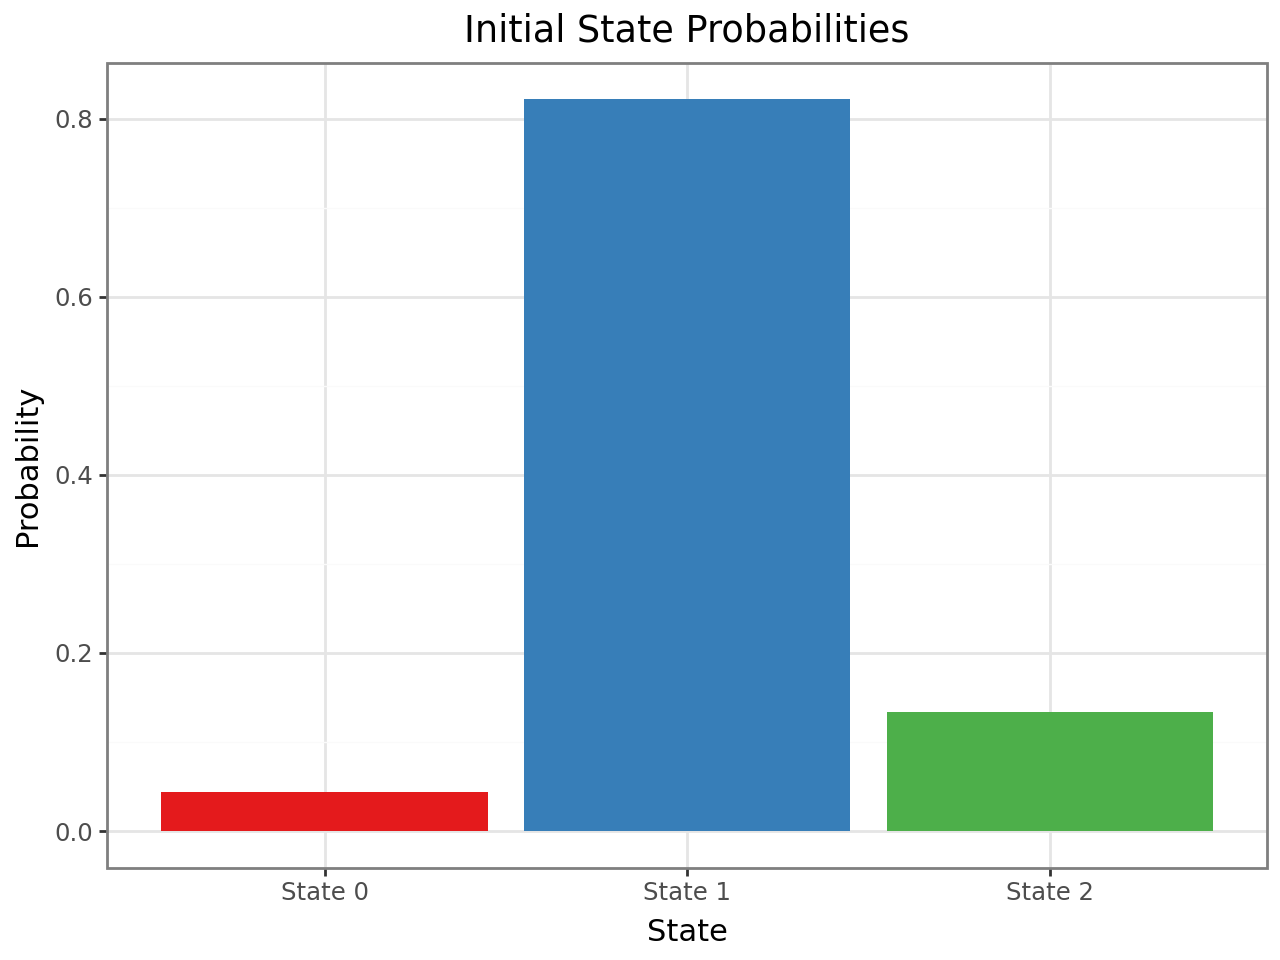

In [58]:
plots["init"]

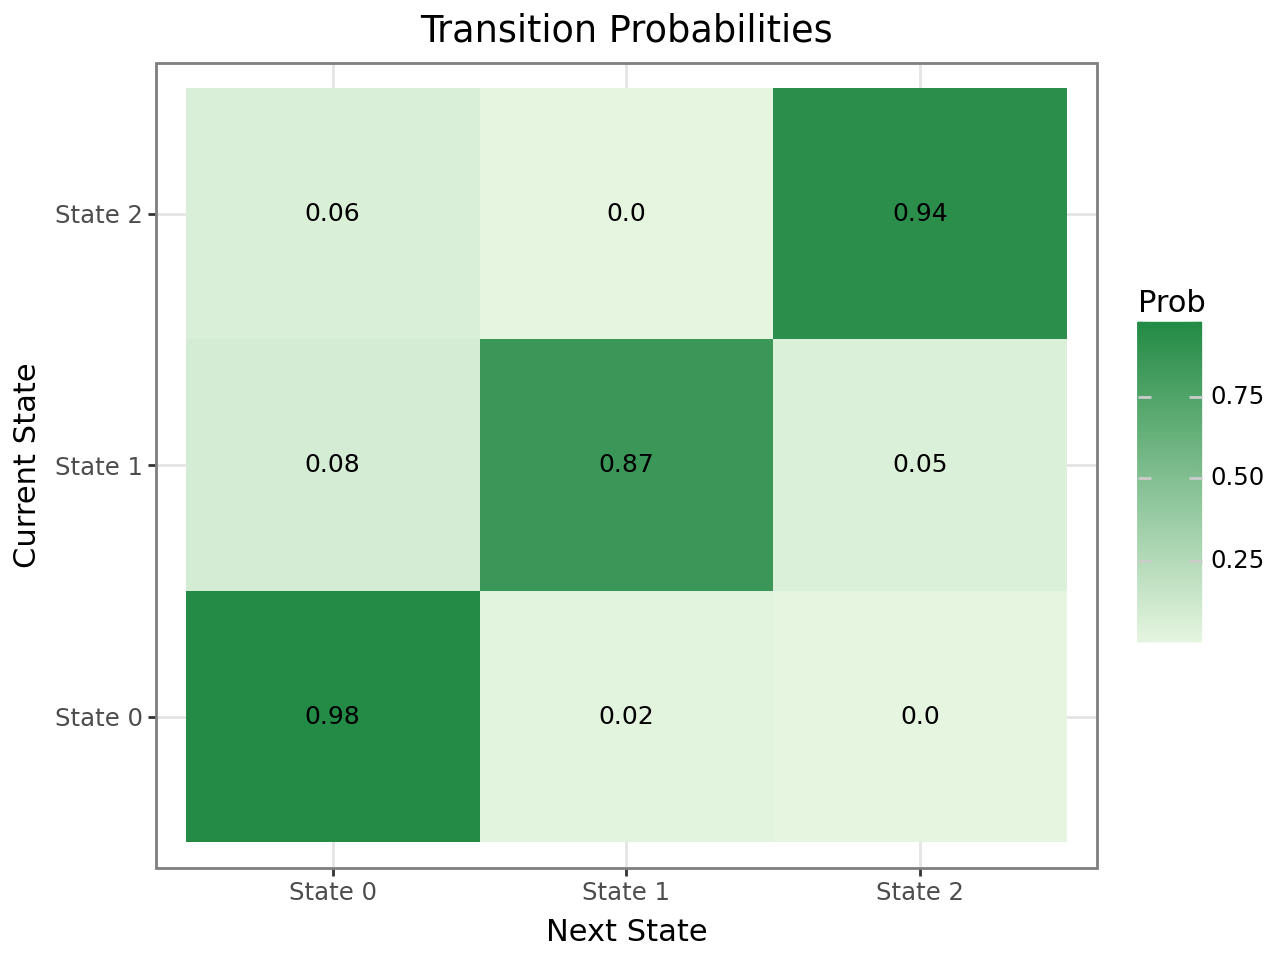

In [59]:
plots['trans']

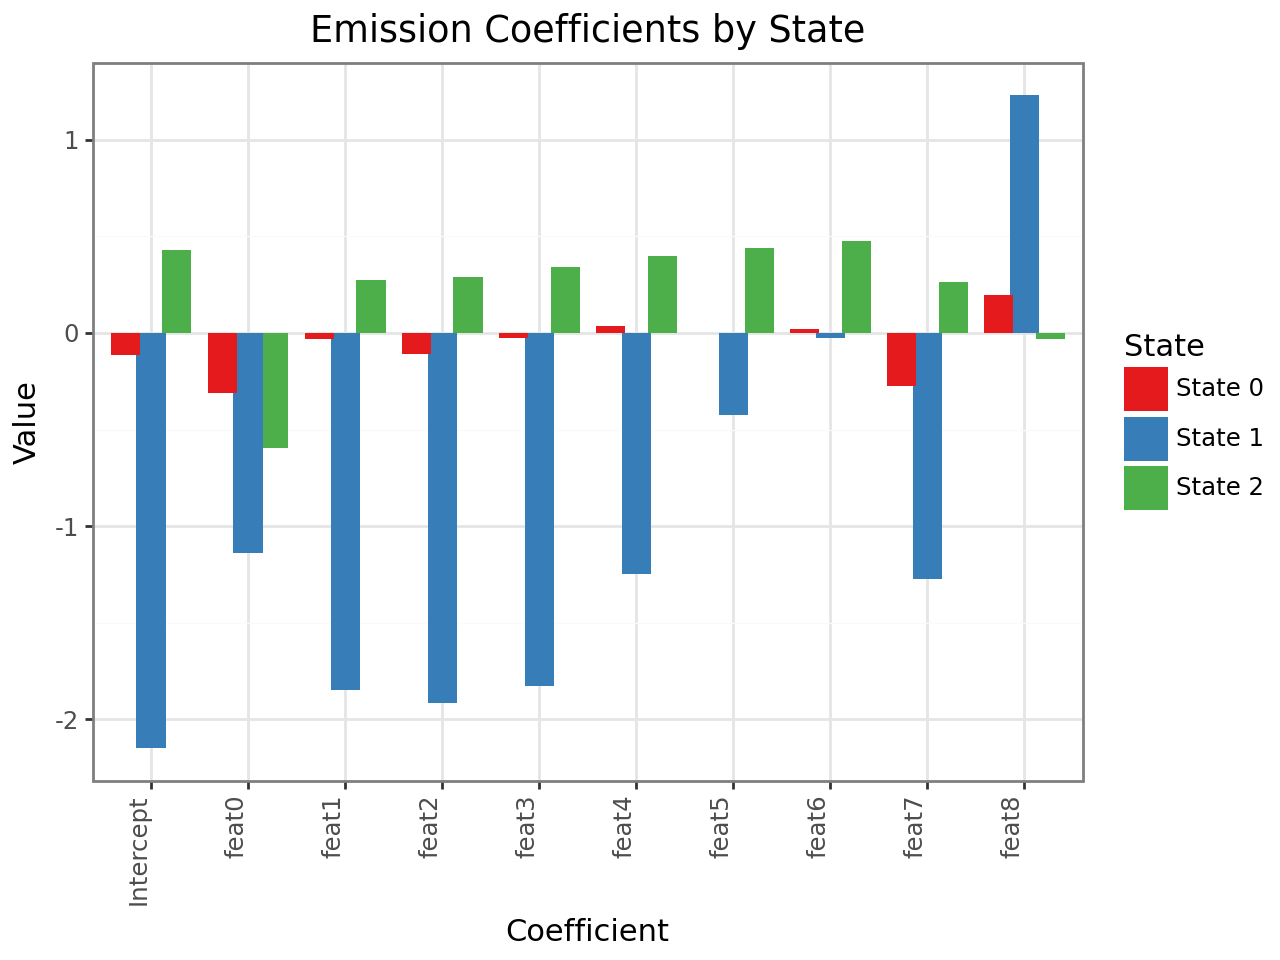

In [60]:
plots['coeffs']

In [61]:
pyro.get_param_store().set_state(best_params[5])

def softmax_row(v):
    e = np.exp(v - np.max(v, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

# 1) Extract learned parameters
pi_base = pyro.param("pi_base_map").detach().cpu().numpy()      # (K,) simplex
A_base  = pyro.param("A_base_map").detach().cpu().numpy()       # (K, K) rows on simplex
W_pi    = pyro.param("W_pi").detach().cpu().numpy()             # (K, C_pi)
W_A     = pyro.param("W_A").detach().cpu().numpy()              # (K, K, C_A)
beta_em = pyro.param("beta_em").detach().cpu().numpy()          # (K, 1 + C_em) if intercept first


In [63]:
# 2) Covariate means
x_mean_pi = cov_init_torch.mean(dim=0).detach().cpu().numpy()        # (C_pi,)
x_mean_A  = cov_tran_torch.mean(dim=(0, 1)).detach().cpu().numpy()   # (C_A,)

# 3) Mean initial probs and transitions under average covariates
logits_pi = np.log(pi_base + 1e-30) + W_pi @ x_mean_pi
pi_mean   = softmax_row(logits_pi[None, :]).ravel()

K = pi_mean.shape[0]
A_mean = np.zeros((K, K))
for k in range(K):
    logits_row = np.log(A_base[k] + 1e-30) + (W_A[k] @ x_mean_A)
    A_mean[k] = softmax_row(logits_row[None, :]).ravel()

# 4) Names
state_names = [f"State {i}" for i in range(K)]

# Infer emission coefficient names from beta_em shape
C_em = beta_em.shape[1] - 1  # exclude intercept
coeff_names = [f"feat{i}" for i in range(C_em)]
include_intercept = True

# Optional check: ensure consistency with your covariate tensor
if 'cov_emiss_torch' in globals():
    C_em_from_tensor = int(cov_emiss_torch.shape[-1])
    if C_em_from_tensor != C_em:
        print(f"Warning: beta_em has {C_em} coefficients, but cov_emission tensor has {C_em_from_tensor} features.")



In [64]:
plots = plot_hmm_params_with_coeffs(
    transitions=A_mean,
    initial_probs=pi_mean,
    beta_em=beta_em,
    state_names=state_names,
    coeff_names=coeff_names,
    include_intercept=include_intercept,
    intercept_name="Intercept"
)

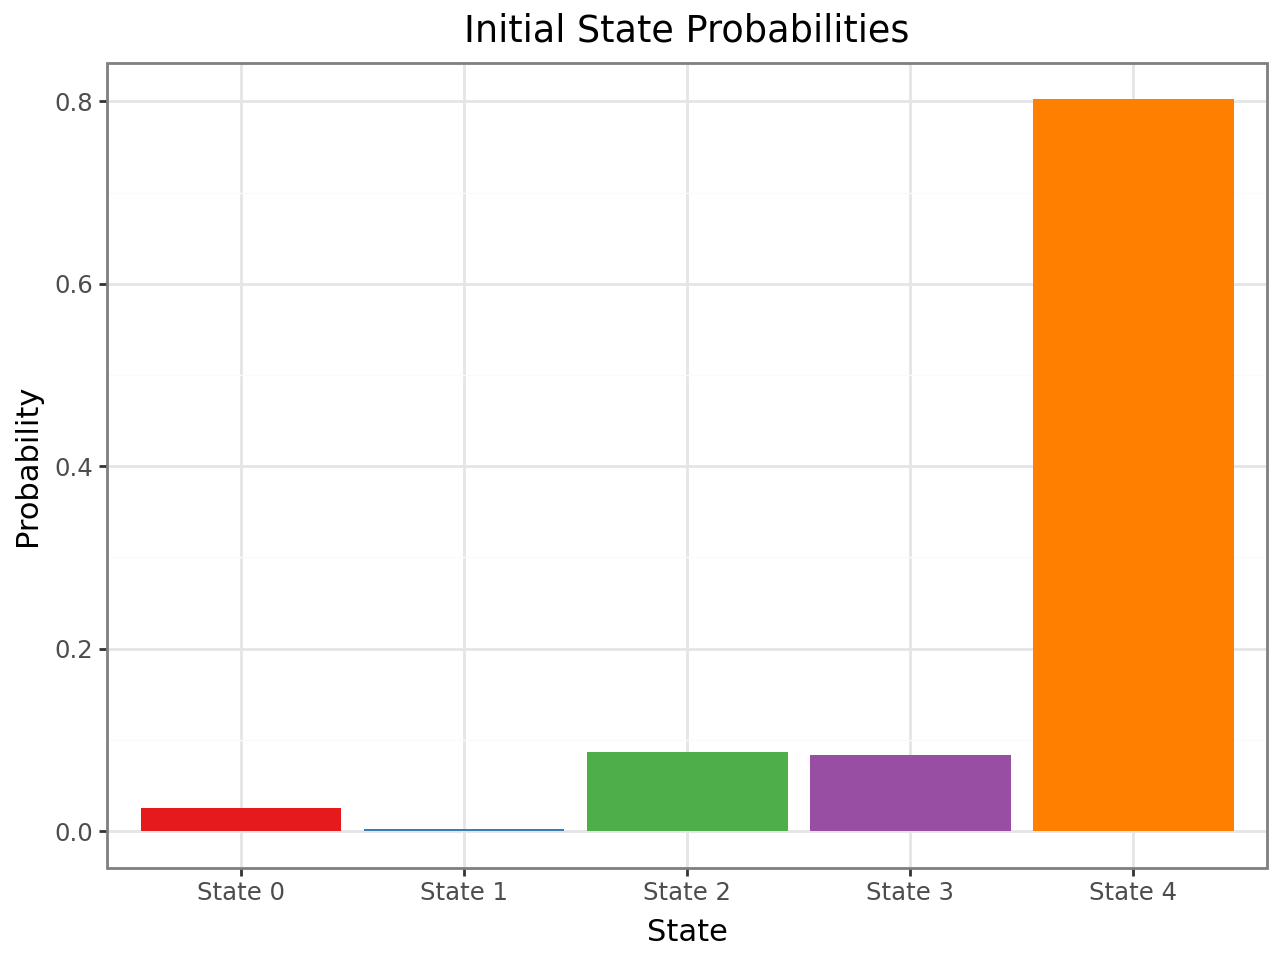

In [65]:
plots['init']

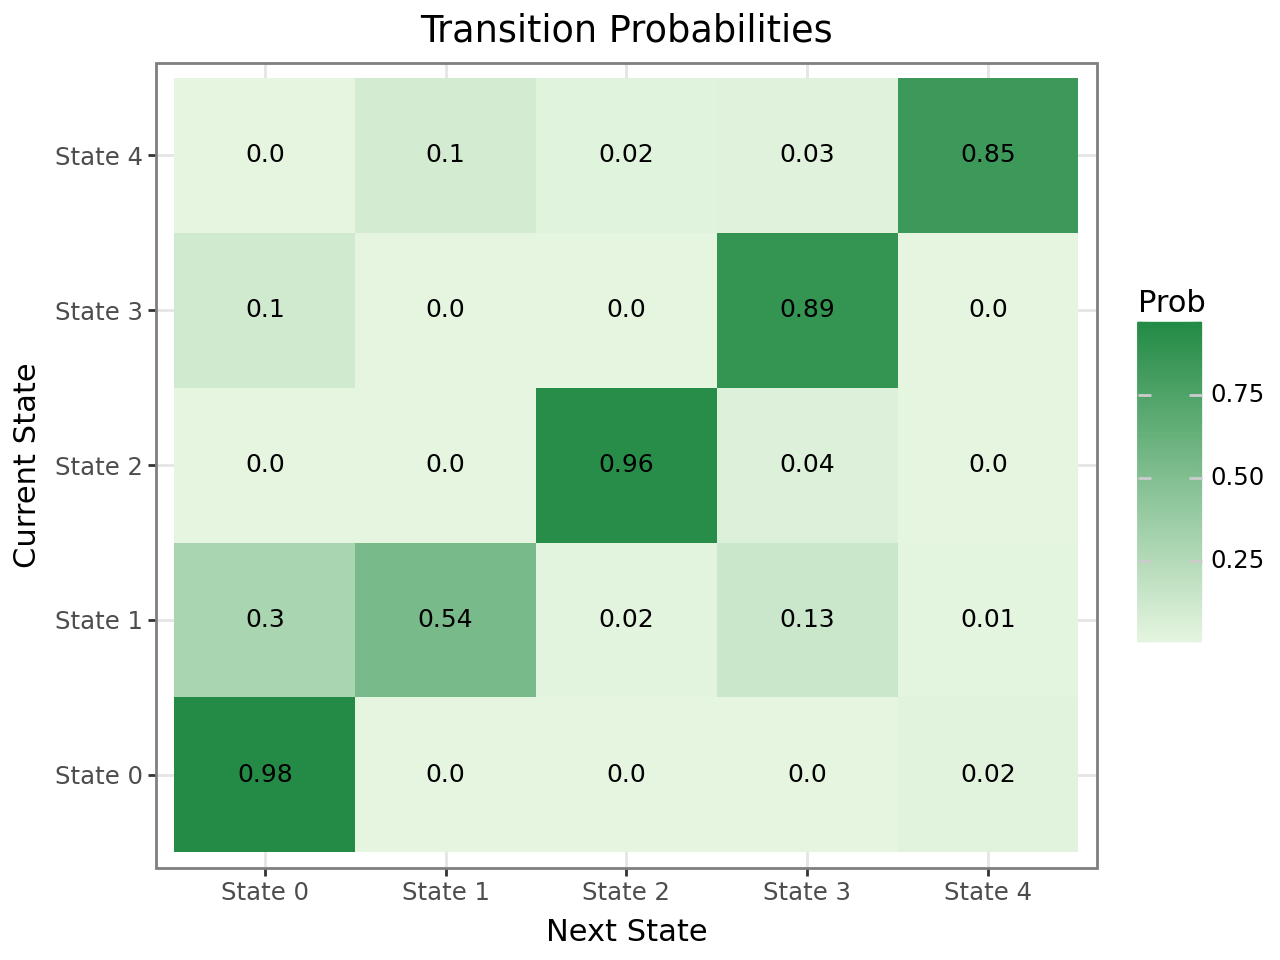

In [66]:
plots['trans']

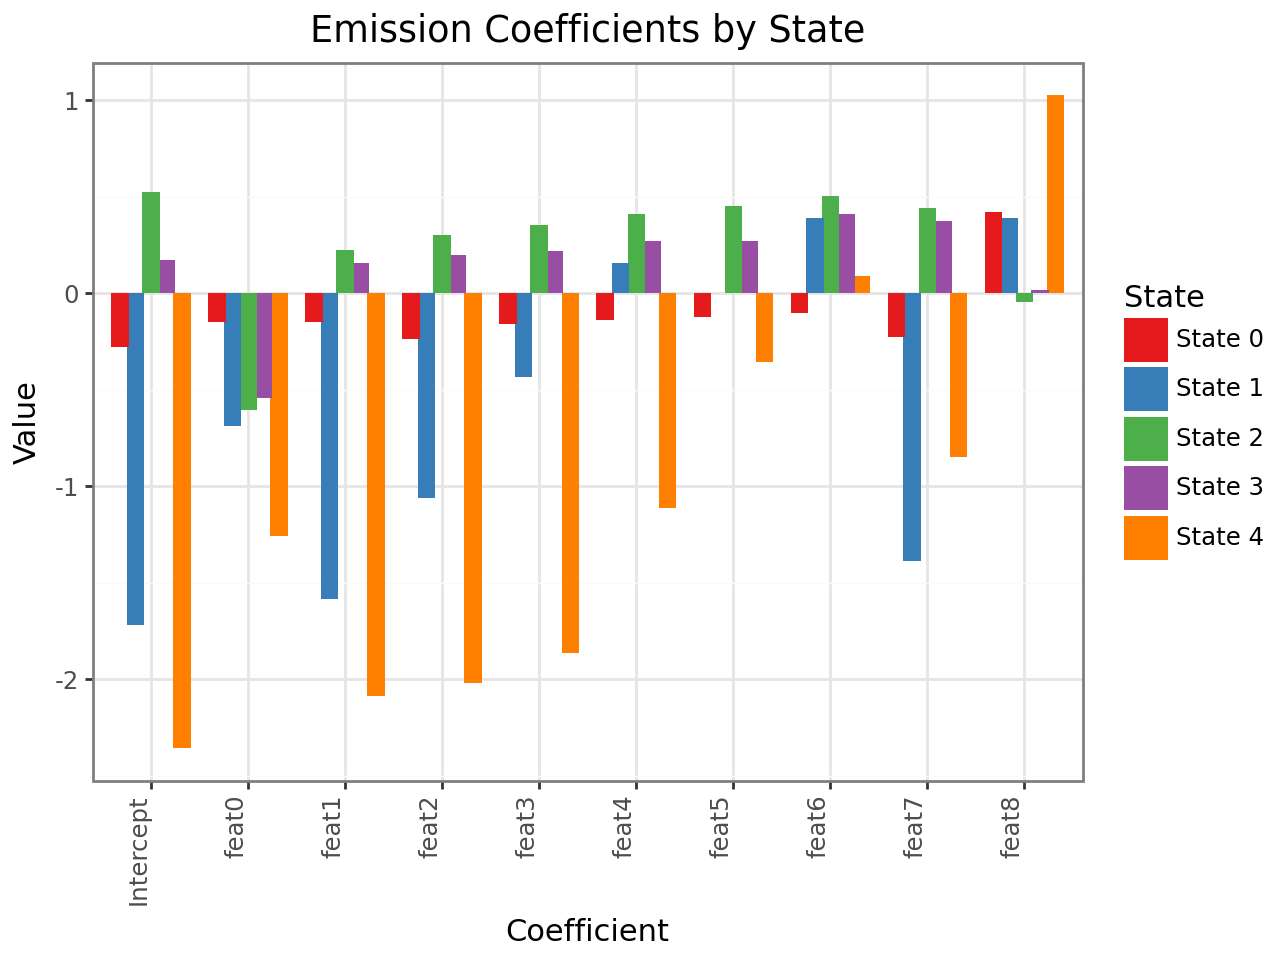

In [67]:
plots['coeffs']

In [ ]:
y_train = obs_train[:, -1].float()
X_train = cov_train  #(... , 10)

X_test = cov_test
y_test = obs_test[:, -1].float()

tensor([0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 3., 3., 0., 2., 1.,
        1., 2., 2., 0., 2., 1., 1., 2., 0., 2., 0., 0., 2., 1., 0., 3., 2., 1.,
        0., 0., 1., 0., 0., 2., 0., 0., 2., 1., 2., 0., 0., 0., 1., 2., 0., 0.,
        0., 0., 0., 2., 1., 2., 1., 0., 0., 0., 0., 0., 2., 0., 3., 0., 1., 0.,
        0., 0., 1., 0., 0., 1., 1., 1., 1., 3., 0., 2., 1., 1., 2., 0., 0., 0.,
        0., 2., 2., 0., 1., 1., 0., 1., 1., 1., 3., 0., 0., 2., 0., 3., 0., 4.,
        2., 3., 1., 0., 2., 0., 1., 1., 1., 1., 2., 0., 3., 3., 1., 2., 0., 0.,
        1., 0., 0., 0., 2., 3., 0., 0., 0., 1., 1., 2., 0., 1., 1., 1., 0., 2.,
        3., 0., 1., 0., 0., 2., 0., 2., 3., 1., 2., 0., 1., 1., 0., 2., 2., 0.,
        1., 3., 1., 0., 0., 1., 0., 1., 0., 1., 2., 0., 3., 0., 1., 2., 1., 0.,
        0., 1., 3., 1., 0., 0., 1., 0., 1., 1., 0., 2., 1., 3., 0., 0., 4., 0.,
        2., 0., 0., 0., 2., 2., 1., 0., 0., 2., 0., 0., 1., 0., 1., 1., 0., 2.,
        0., 1., 2., 2., 1., 1., 1., 0., 

In [75]:
# ---------------------------
# Poisson GLM with log link
# ---------------------------
def glm_poisson_model(X, y=None, param_name="glm_beta"):
    # X: (N, C), y: (N,)
    assert X.dim() == 2, "X must be (N, C)"
    N, C = X.shape
    beta = pyro.param(param_name, torch.zeros(C + 1, device=X.device))  # intercept + C slopes
    log_mu = beta[0] + (X @ beta[1:].unsqueeze(-1)).squeeze(-1)         # (N,)
    mu = log_mu.exp()
    with pyro.plate("data", N):
        pyro.sample("obs", dist.Poisson(mu), obs=y)

def glm_poisson_guide(X, y=None, param_name="glm_beta"):
    # Mean-field guide is empty: we use point estimates via pyro.param in the model.
    pass

# ---------------------------
# Train
# ---------------------------
def fit_glm_poisson(X, y, steps=3000, lr=1e-2, param_name="glm_beta", verbose_every=500, save_path="glm_poisson_params.pt"):
    X = X.detach()
    y = y.detach().float()  # Poisson log_prob accetta float
    pyro.clear_param_store()
    svi = SVI(
        lambda X_, y_: glm_poisson_model(X_, y_, param_name),
        lambda X_, y_: glm_poisson_guide(X_, y_, param_name),
        Adam({"lr": lr}),
        loss=Trace_ELBO()
    )
    loss_hist = []
    for s in range(steps):
        loss = svi.step(X, y)
        if verbose_every and s % verbose_every == 0:
            print(f"step {s:4d}: loss={loss:.3f}")
        loss_hist.append(loss)
    # Save only the GLM params (store currently contains only them if you cleared before)
    pyro.get_param_store().save(save_path)
    return loss_hist


In [83]:
from pyro.infer import SVI, Trace_ELBO

loss_hist = fit_glm_poisson(X_train, y_train, steps=100, lr=1e-1, verbose_every=10)


step    0: loss=11023.613
step   10: loss=10700.510
step   20: loss=10664.460
step   30: loss=10654.617
step   40: loss=10654.635
step   50: loss=10651.855
step   60: loss=10650.818
step   70: loss=10650.536
step   80: loss=10650.448
step   90: loss=10650.429


In [82]:
pyro.get_param_store().load("glm_poisson_params.pt", map_location="cpu", weights_only=False)


TypeError: ParamStoreDict.load() got an unexpected keyword argument 'weights_only'

In [85]:
# ---------------------------
# Predict and metrics
# ---------------------------
@torch.no_grad()
def glm_poisson_predict(X, param_name="glm_beta", return_proba=True):
    X = X.detach()
    beta = pyro.param(param_name)
    log_mu = beta[0] + (X @ beta[1:].unsqueeze(-1)).squeeze(-1)
    mu = log_mu.exp()  # expected counts
    if return_proba:
        p_donate = 1.0 - torch.exp(-mu)  # P(Y>0 | mu)
        return mu, p_donate
    return mu

@torch.no_grad()
def glm_poisson_evaluate(X, y, param_name="glm_beta"):
    X = X.detach()
    y = y.detach().float()
    mu = glm_poisson_predict(X, param_name, return_proba=False)
    # Metrics
    mae = torch.mean(torch.abs(mu - y)).item()
    rmse = torch.sqrt(torch.mean((mu - y) ** 2)).item()
    # Poisson NLL per observation: -log p(y|mu) = mu - y*log(mu) + log(y!)
    # Use dist.Poisson for stable log_prob
    nll = -torch.mean(dist.Poisson(mu).log_prob(y)).item()
    brier = torch.mean(( (1.0 - torch.exp(-mu)) - (y > 0).float() ) ** 2).item()
    return {"MAE": mae, "RMSE": rmse, "NLL": nll, "Brier(y>0)": brier}

In [95]:
mu_te, p_donate_te = glm_poisson_predict(X_test)


In [97]:
metrics_te = glm_poisson_evaluate(X_test, y_test)
metrics_te

{'MAE': 0.8410829901695251,
 'RMSE': 1.0062100887298584,
 'NLL': 1.2684494256973267,
 'Brier(y>0)': 0.2460843175649643}

## Confronto modello base ##

In [21]:
# ------------------------------------------------------------------ #
# FUNZIONE PER ALLENARE HMM CON DIVERSI K                            #
# ------------------------------------------------------------------ #
def train_hmm_models(obs, K_values= [3,5] , n_steps=800, n_inits=3, lr=0.05):
    results = {}  # dict: K -> lista di loss finali per ogni seed
    best_losses = {}  # dict: K -> best loss tra i seed

    for K in K_values:
        print("\n" + "="*50)
        print(f" Allenamento modello con K = {K} stati ")
        print("="*50)

        results[K] = []

        for i in range(n_inits):
            print(f" Seed= {i}")
            pyro.set_rng_seed(i)
            pyro.clear_param_store()

            # ------------------------------
            # MODEL
            # ------------------------------
            def model(obs):
                N, T = obs.shape
                pi = pyro.sample("pi", dist.Dirichlet(torch.ones(K)))   # [K]
                with pyro.plate("row", K):
                    A = pyro.sample("A", dist.Dirichlet(torch.ones(K))) # [K,K]
                rates = pyro.sample("rates",
                                    dist.Gamma(2.*torch.ones(K),
                                            1.*torch.ones(K)).to_event(1))
                with pyro.plate("donor", N):
                    z = pyro.sample("z_0", dist.Categorical(pi),
                                    infer={"enumerate": "parallel"})
                    for t in pyro.markov(range(T)):
                        pyro.sample(f"y_{t}", dist.Poisson(rates[z]), obs=obs[:, t])
                        if t < T-1:
                            z = pyro.sample(f"z_{t+1}", dist.Categorical(A[z]),
                                            infer={"enumerate": "parallel"})

            # ------------------------------
            # GUIDE
            # ------------------------------
            def guide(obs):
                pi_alpha = pyro.param("pi_alpha", torch.ones(K),
                                    constraint=dist.constraints.positive)
                A_alpha = pyro.param("A_alpha", torch.ones(K, K),
                                    constraint=dist.constraints.positive)
                r_alpha = pyro.param("r_alpha", 2.*torch.ones(K),
                                    constraint=dist.constraints.positive)
                r_beta  = pyro.param("r_beta", 1.*torch.ones(K),
                                    constraint=dist.constraints.positive)

                pyro.sample("pi", dist.Dirichlet(pi_alpha))
                with pyro.plate("row", K):
                    pyro.sample("A", dist.Dirichlet(A_alpha))
                pyro.sample("rates", dist.Gamma(r_alpha, r_beta).to_event(1))

            # ------------------------------
            # TRAINING
            # ------------------------------
            svi = SVI(model, guide, Adam({"lr": lr}),
                    loss=TraceEnum_ELBO(max_plate_nesting=1))

            loss = None
            for step in range(n_steps):
                loss = svi.step(obs)
                if step % 100 == 0:
                    print(f"{step:4d}  ELBO = {loss:,.0f}")

            results[K].append(loss)  # salva la loss finale di questo seed

        # migliore loss per questo K
        best_losses[K] = min(results[K])
        print(f"\n --> Migliore loss per K={K}: {best_losses[K]:,.0f}")

    # ------------------------------
    # RIEPILOGO FINALE
    # ------------------------------
    print("\n\nRISULTATI FINALI:")
    best_K = min(best_losses, key=best_losses.get)
    for K in K_values:
        arrow = "  <-- migliore" if K == best_K else ""
        print(f"K = {K:2d} | Loss min su {n_inits} seed = {best_losses[K]:,.0f}{arrow}")

    return best_K, results, best_losses

In [22]:
best_K, results, best_losses = train_hmm_models(obs_torch, K_values=[3,5], n_inits=3, n_steps=500, lr=0.05)


 Allenamento modello con K = 3 stati 
 Seed= 0
   0  ELBO = 249,663
 100  ELBO = 154,770
 200  ELBO = 151,829
 300  ELBO = 143,833
 400  ELBO = 134,268
 Seed= 1
   0  ELBO = 224,909
 100  ELBO = 152,511
 200  ELBO = 163,748
 300  ELBO = 139,742
 400  ELBO = 135,252
 Seed= 2
   0  ELBO = 223,440
 100  ELBO = 151,723
 200  ELBO = 140,243
 300  ELBO = 135,000
 400  ELBO = 138,584

 --> Migliore loss per K=3: 131,856

 Allenamento modello con K = 5 stati 
 Seed= 0
   0  ELBO = 217,082
 100  ELBO = 146,315
 200  ELBO = 140,187
 300  ELBO = 142,657
 400  ELBO = 132,562
 Seed= 1
   0  ELBO = 189,446
 100  ELBO = 142,119
 200  ELBO = 134,413
 300  ELBO = 133,304
 400  ELBO = 133,632
 Seed= 2
   0  ELBO = 194,776
 100  ELBO = 146,348
 200  ELBO = 133,447
 300  ELBO = 134,406
 400  ELBO = 132,992

 --> Migliore loss per K=5: 130,453


RISULTATI FINALI:
K =  3 | Loss min su 3 seed = 131,856
K =  5 | Loss min su 3 seed = 130,453  <-- migliore


In [19]:
best_K

2

In [ ]:
# alleno di nuovo il modello migliore
pyro.clear_param_store()
pyro.set_rng_seed(0)  # oppure il seed che aveva dato la loss minima
K = best_K
def model(obs):
                N, T = obs.shape
                pi = pyro.sample("pi", dist.Dirichlet(torch.ones(K)))   # [K]
                with pyro.plate("row", K):
                    A = pyro.sample("A", dist.Dirichlet(torch.ones(K))) # [K,K]
                rates = pyro.sample("rates",
                                    dist.Gamma(2.*torch.ones(K),
                                            1.*torch.ones(K)).to_event(1))
                with pyro.plate("donor", N):
                    z = pyro.sample("z_0", dist.Categorical(pi),
                                    infer={"enumerate": "parallel"})
                    for t in pyro.markov(range(T)):
                        pyro.sample(f"y_{t}", dist.Poisson(rates[z]), obs=obs[:, t])
                        if t < T-1:
                            z = pyro.sample(f"z_{t+1}", dist.Categorical(A[z]),
                                            infer={"enumerate": "parallel"})



def guide(obs):
                pi_alpha = pyro.param("pi_alpha", torch.ones(K),
                                    constraint=dist.constraints.positive)
                A_alpha = pyro.param("A_alpha", torch.ones(K, K),
                                    constraint=dist.constraints.positive)
                r_alpha = pyro.param("r_alpha", 2.*torch.ones(K),
                                    constraint=dist.constraints.positive)
                r_beta  = pyro.param("r_beta", 1.*torch.ones(K),
                                    constraint=dist.constraints.positive)

                pyro.sample("pi", dist.Dirichlet(pi_alpha))
                with pyro.plate("row", K):
                    pyro.sample("A", dist.Dirichlet(A_alpha))
                pyro.sample("rates", dist.Gamma(r_alpha, r_beta).to_event(1))

            # ------------------------------
            # TRAINING
            # ------------------------------
            svi = SVI(model, guide, Adam({"lr": lr}),
                    loss=TraceEnum_ELBO(max_plate_nesting=1))

            loss = None
            for step in range(n_steps):
                loss = svi.step(obs)
                if step % 100 == 0:
                    print(f"{step:4d}  ELBO = {loss:,.0f}")



TypeError: model() takes 1 positional argument but 4 were given

In [13]:
import torch, pyro, torch.nn.functional as F
import pyro.distributions as dist

def log_softmax_logits(logits, dim=-1):
    return logits - logits.logsumexp(dim, keepdim=True)

@torch.no_grad()
def viterbi_paths_cov(obs, x_pi, x_A, x_em=None):
    """
    Viterbi per HMM con:
      - π dipendente da x_pi via W_pi e base pi_base_map
      - A dipendente da x_A via W_A e base A_base_map
      - emissione:
          • GLM Poisson (beta_em) se disponibile e x_em fornito
          • altrimenti Poisson a tasso costante per stato (rates)
    Input:
      obs  : (N,T) long
      x_pi : (N,C_pi)
      x_A  : (N,T,C_A)
      x_em : (N,T,C_em) richiesto se beta_em è nel ParamStore
    Output:
      paths: (N,T) long, percorso MAP per ogni sequenza
    """
    # -------- parametri appresi ----------
    pi_base = pyro.param("pi_base_map")           # (K,)
    A_base  = pyro.param("A_base_map")            # (K,K)
    W_pi    = pyro.param("W_pi")                  # (K,C_pi)
    W_A     = pyro.param("W_A")                   # (K,K,C_A)

    use_glm = "beta_em" in pyro.get_param_store()
    if use_glm:
        beta_em = pyro.param("beta_em")           # (K, 1 + C_em)

    # Device & dtype alignment
    device = W_pi.device
    obs   = obs.to(device)
    x_pi  = x_pi.to(device)
    x_A   = x_A.to(device)
    if use_glm:
        if x_em is None:
            raise ValueError("x_em è richiesto perché beta_em è nel ParamStore.")
        x_em = x_em.to(device)

    N, T = obs.shape
    K    = pi_base.shape[0]

    # -------- emission log-prob ----------
    if use_glm:
        b0 = beta_em[:, 0]              # (K,)
        B  = beta_em[:, 1:]             # (K,C_em)
        # eta = b0_k + x_em @ B_k
        eta = torch.einsum("ntc,kc->ntk", x_em, B) + b0.view(1,1,K)   # (N,T,K)
        emis_log = dist.Poisson(rate=eta.exp()).log_prob(obs.unsqueeze(-1))  # (N,T,K)
    else:
        rates = pyro.param("rates")      # (K,)
        emis_log = torch.stack(
            [dist.Poisson(l).log_prob(obs) for l in rates]            # (K,N,T)
        ).permute(1, 2, 0)                                            # (N,T,K)

    # -------- inizializzazione (t=0) -----
    log_pi_base = (pi_base + 1e-30).log()               # (K,)
    logits0     = log_pi_base + x_pi @ W_pi.T           # (N,K)
    log_pi      = log_softmax_logits(logits0, dim=1)    # (N,K)

    delta = log_pi + emis_log[:, 0]                     # (N,K)
    psi   = torch.zeros(N, T, K, dtype=torch.long, device=device)

    # -------- forward pass --------------
    log_A_base = (A_base + 1e-30).log()                 # (K,K)
    for t in range(1, T):
        x_t   = x_A[:, t, :]                            # (N,C_A)
        # logits[n,k_prev,k_next] = log A_base + <W_A[k_prev,k_next], x_t[n,:]>
        slope  = (W_A.unsqueeze(0) * x_t[:, None, None, :]).sum(-1)   # (N,K,K)
        logits = log_A_base.unsqueeze(0) + slope                       # (N,K,K)
        log_A  = log_softmax_logits(logits, dim=2)                     # row-softmax

        score, idx = (delta.unsqueeze(2) + log_A).max(dim=1)           # max su k_prev
        psi[:, t]  = idx
        delta      = score + emis_log[:, t]

    # -------- back-tracking -------------
    paths        = torch.empty(N, T, dtype=torch.long, device=device)
    last_state   = delta.argmax(dim=1)
    paths[:, -1] = last_state
    for t in range(T-1, 0, -1):
        last_state    = psi[torch.arange(N, device=device), t, last_state]
        paths[:, t-1] = last_state

    return paths.cpu()

In [14]:
paths = viterbi_paths_cov(
    obs_torch,
    cov_init_torch,    # (N,C_pi)
    cov_tran_torch,    # (N,T,C_A)
    cov_emiss_torch    # (N,T,C_em)
)

KeyError: 'pi_base_map'

In [ ]:
import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_point, geom_step,
    scale_color_manual, scale_x_continuous, scale_y_continuous,
    labs, theme_minimal, theme, element_text, element_line, element_blank,
    guides, guide_legend
)

# ------------------------------------------------------------
# globals (kept similar to original)
# ------------------------------------------------------------
K_default   = 3
state_cols_default = ['#e41a1c', '#377eb8', '#4daf4a']  # 3 Set1 colors
years_axis  = np.arange(2009, 2024)                    # 2009 .. 2023
yticks_vals = np.arange(0, 5)                          # 0 .. 4

def plot_one_gg(idx, obs_torch, paths, years=years_axis, state_cols=None, y_max=4, title_prefix="Donor"):
    """
    Recreates the original scatter+step plot with plotnine:
      - observed counts (step + points)
      - points colored by discrete latent states with a clean legend
      - x-ticks labeled with years, y-limits clamped to [-0.5, y_max+0.5]
    """
    # -------- extract donor data --------
    x = obs_torch[idx].detach().cpu().numpy() if hasattr(obs_torch, "detach") else np.asarray(obs_torch[idx])
    z = paths[idx].detach().cpu().numpy()     if hasattr(paths, "detach")     else np.asarray(paths[idx], dtype=int)
    years = np.asarray(years, dtype=int)

    T = len(x)
    if len(years) != T:
        raise ValueError("years length must match T for the selected donor.")

    # -------- palette and labels --------
    K = int(np.max(z)) + 1 if z.size > 0 else (state_cols and len(state_cols)) or K_default
    if state_cols is None:
        state_cols = state_cols_default[:K]
    state_labels = [f"State {k}" for k in range(K)]
    z_labs = [state_labels[s] for s in z]

    # -------- build dataframe ----------
    df = pd.DataFrame({
        "t": np.arange(T),
        "year": years,
        "donations": x,
        "state": z_labs
    })

    # -------- assemble plot ------------
    p = (
        ggplot(df, aes("t", "donations"))
        + geom_step(direction="mid", color="black", alpha=0.35)
        + geom_point(aes(color="state"), size=2.6)
        + scale_color_manual(values=state_cols, name="latent state",
                             breaks=state_labels, labels=state_labels)
        + scale_x_continuous(breaks=list(range(T)), labels=[str(y) for y in years])
        + scale_y_continuous(limits=(-0.5, float(y_max) + 0.5), breaks=list(range(0, int(y_max) + 1)))
        + labs(title=f"{title_prefix} {idx}", x="year", y="# donations")
        + theme_minimal()
        + theme(
            axis_text_x=element_text(rotation=45, ha="right"),
            legend_title=element_text(size=10),
            legend_text=element_text(size=9),
            plot_title=element_text(weight="bold"),
            # mimic dotted y-grid only
            panel_grid_major_y=element_line(linetype="dotted", alpha=0.4),
            panel_grid_major_x=element_blank(),
            panel_grid_minor=element_blank()
        )
        + guides(color=guide_legend(title="latent state"))
    )
    return p
